In [1]:
from utils import *
from concurrent.futures import ProcessPoolExecutor
import concurrent
%matplotlib inline

bare osc freq: 9.85
qubit bare energy:
0-3: 3.168531225431973
1-4: 2.5673705659408856
2-5: 3.0073323359673334
1-6: 3.8177132027171887
2-7: 5.090766706752516
1-2 0.009204959072095065

differential_stark_on_qubit_12 transition
osc 0: 0.009196214372325873
osc 1:0.009208468940141046, diff to previous 1.225456781517309e-05
osc 2:0.00922074360338243, diff to previous 1.2274663241385042e-05
osc 3:0.009233038284413908, diff to previous 1.229468103147724e-05
osc 4:0.00924535290521078, diff to previous 1.2314620796871623e-05
osc 5:0.009257687391205138, diff to previous 1.2334485994358602e-05
osc 6:0.009270041666880502, diff to previous 1.2354275675363624e-05
osc 7:0.009282415660692322, diff to previous 1.2373993811820583e-05

differential_stark_on_qubit_01 transition
osc 0: 2.3936066044308006
osc 1:2.3921535413250474, diff to previous -0.0014530631057532162
osc 2:2.391083076471734, diff to previous -0.0010704648533135241
osc 3:2.390165004587761, diff to previous -0.0009180718839729707
osc 4:2.38

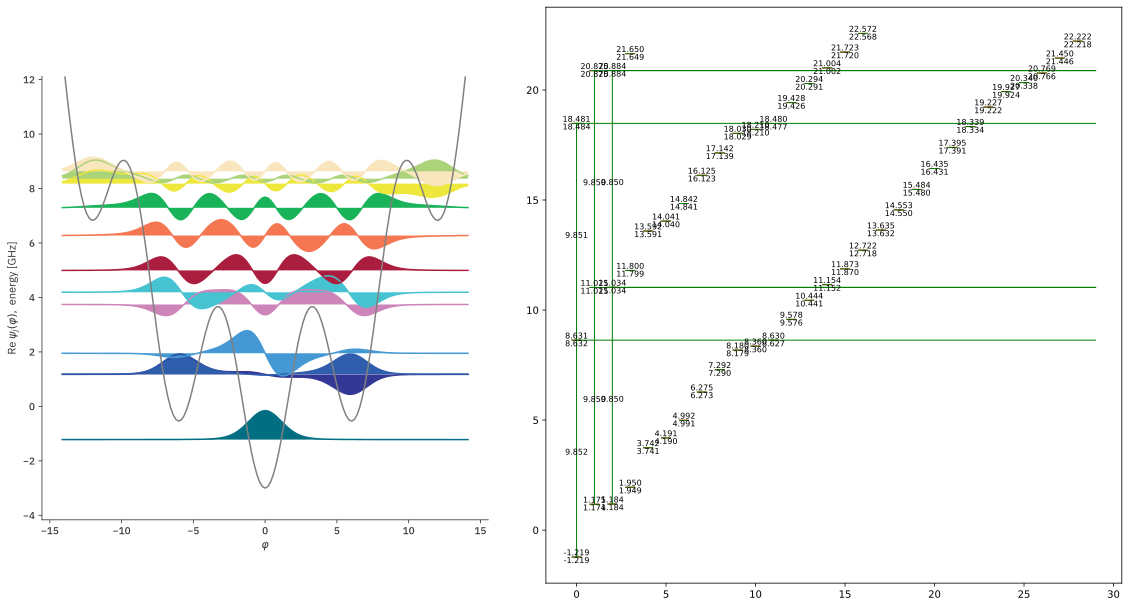

In [2]:
g_strength = 0.1

# EJ = 3
# EC = 0.8
# EL = 0.09
# E_osc  = 6.7371

EJ = 3
EC = 0.6
EL = 0.13
E_osc = 9.85

# EJ = 3
# EC = 0.75
# EL = 0.1
# # E_osc = 9.846
# E_osc = 7.89

qubit_level = 30
osc_level = 60
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)


evals = qbt.eigenvals(13)
# E_osc = evals[11]-evals[0]
# E_osc = 7
print(f'bare osc freq: {E_osc}')


osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
energies=  hilbertspace.eigenvals(qubit_level*osc_level)
def dressed_ener(ql,ol):
    return energies[product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"qubit bare energy:")
    print(f"0-3: {evals[3]-evals[0]}")
    print(f"1-4: {evals[4]-evals[1]}")
    print(f"2-5: {evals[5]-evals[2]}")
    print(f"1-6: {evals[6]-evals[1]}")
    print(f"2-7: {evals[7]-evals[2]}")
    print(f"1-2 {qbt.eigenvals()[2]-qbt.eigenvals()[1]}")


    print(f"\ndifferential_stark_on_qubit_12 transition")
    print(f"osc {0}: {(dressed_ener(2,0)-dressed_ener(1,0))}")
    for i in range(1,8):
        print(f"osc {i}:{(dressed_ener(2,i)-dressed_ener(1,i))}, diff to previous {(dressed_ener(2,i)-dressed_ener(1,i))  -(dressed_ener(2,i-1)-dressed_ener(1,i-1))}")

    print(f"\ndifferential_stark_on_qubit_01 transition")
    print(f"osc {0}: {(dressed_ener(1,0)-dressed_ener(0,0))}")
    for i in range(1,8):
        print(f"osc {i}:{(dressed_ener(1,i)-dressed_ener(0,i))}, diff to previous {(dressed_ener(1,i)-dressed_ener(0,i))  -(dressed_ener(1,i-1)-dressed_ener(0,i-1))}")


    print(f"\nfor qubit in \t1 \t 2 \t\t 0 \t\t 3:")
    print(f"osc 0-1: \t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,10):
        print(f"osc {i}-{i+1}: \t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  non-linearity of 0 to previous {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,i)-dressed_ener(0,i-1))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()

plot_specturum(qbt, osc, hilbertspace,num_levels = 50)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

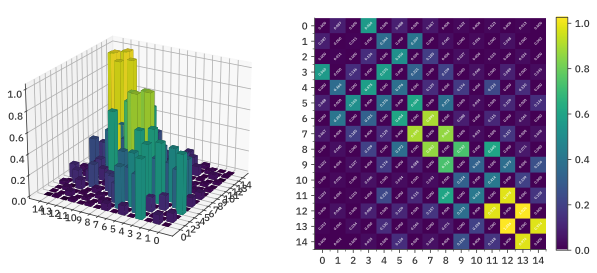

In [3]:
qbt.plot_matrixelements('n_operator',evals_count=15,show_numbers=1)

computational freq 0.009204959072093732


Er loop:   0%|          | 0/800 [00:00<?, ?it/s]

Er loop:   0%|          | 0/800 [00:00<?, ?it/s]

Er loop:   0%|          | 0/800 [00:00<?, ?it/s]

Er loop:   0%|          | 0/800 [00:00<?, ?it/s]

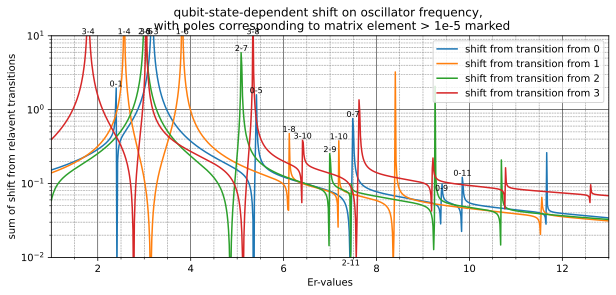

In [4]:
sweep_Er(EJ,EC,EL,np.linspace(1,13,800))

computational freq 0.009204959072093732


Er loop:   0%|          | 0/800 [00:00<?, ?it/s]

Er loop:   0%|          | 0/800 [00:00<?, ?it/s]

Er loop:   0%|          | 0/800 [00:00<?, ?it/s]

Er loop:   0%|          | 0/800 [00:00<?, ?it/s]

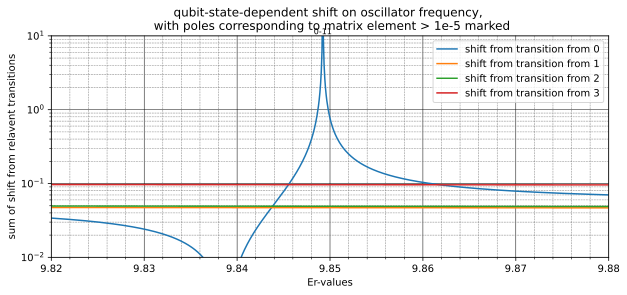

In [5]:
# 0-11
sweep_Er(EJ,EC,EL,np.linspace(9.82,9.88,800))

In [9]:
products_to_keep = []
#want to keep 50 levels for qubit in 0th state
for ol in range(20):
    products_to_keep.append([0,ol])
# keep 5 levels for other qubit levels
for ql in [1,2]:
    for ol in range(50):
        products_to_keep.append([ql,ol])
for ql in [3]:
    for ol in range(50):
        products_to_keep.append([ql,ol])

def truncate_function(qobj):
    return truncate_custom(qobj, products_to_keep, product_to_dressed)


a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
a_trunc = truncate_function(a)

(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])
diag_dressed_hamiltonian = truncate_function(diag_dressed_hamiltonian)

# w_d = transition_frequency(hilbertspace,product_to_dressed[(0,0)],product_to_dressed[(0,1)] )
# w_d  = 9.856
# w_d = 9.85094

# w_d = (transition_frequency(hilbertspace,product_to_dressed[(1,0)],product_to_dressed[(1,1)] ) + transition_frequency(hilbertspace,product_to_dressed[(0,0)],product_to_dressed[(0,1)] ))/2
w_d = transition_frequency(hilbertspace,product_to_dressed[(1,0)],product_to_dressed[(1,1)] ) 
w_d_1 = transition_frequency(hilbertspace,product_to_dressed[(0,7)],product_to_dressed[(0,8)] )


tot_time =338
tlist = np.linspace(0, tot_time, tot_time*2)

amp1 = 0.008
amp2 = 0.004

kappa = 0.005
decay_term = np.sqrt(kappa) * a_trunc


In [10]:
stop_t = 220
stop_t2 = abs(a[product_to_dressed[(0,2)],product_to_dressed[(0,3)]])/amp2

# stop_t, stop_t2

In [11]:
def write_function():
    if os.path.exists('temp_functions.py'):
        os.remove('temp_functions.py')
    with open('temp_functions.py', 'w') as f:
        f.write(f"""
from utils import *
            
w_d = {w_d}
w_d_1 = {w_d_1}
amp1 = {amp1}
amp2 = {amp2}
stop_t = {stop_t}
stop_t2 = {stop_t2}

product_to_dressed = {product_to_dressed}
products_to_keep = {products_to_keep}
def square_cos(t, *args):
    cos = np.cos(w_d * 2 * np.pi * t)
    return 2 * np.pi * amp1 * cos

def square_cos_part1(t, *args):
    if t>stop_t:
        return 0
    else:
        cos = np.cos(w_d * 2 * np.pi * t)
        return 2 * np.pi * amp1 * cos

def square_cos_part2(t, *args):
    if t<=stop_t:
        return 0
    else:
        cos = np.cos(w_d_1 * 2 * np.pi * t)
        return 2 * np.pi * amp2 * cos

    

def pad_back_custom(qobj: qutip.Qobj, products_to_keep: list, product_to_dressed: dict) -> qutip.Qobj:
    indices_to_keep = [dressed_level for (qubit_level, oscillator_level), dressed_level in product_to_dressed.items() if [qubit_level, oscillator_level] in products_to_keep]
    indices_to_keep.sort()

    full_dimension = max(product_to_dressed.values()) + 1

    if qobj.shape[1] == 1:  # is ket
        padded_vector = np.zeros((full_dimension, 1), dtype=complex)
        padded_vector[indices_to_keep, :] = qobj.full()
        return qutip.Qobj(padded_vector)
    else:  # is operator or density matrix
        padded_matrix = np.zeros((full_dimension, full_dimension), dtype=complex)
        padded_matrix[np.ix_(indices_to_keep, indices_to_keep)] = qobj.full()
        return qutip.Qobj(padded_matrix)

def mesolve_and_pad(rho0,
            H_with_drive,
             tlist, 
            full_dim,
            c_ops = None
            ):

            
    temp = qutip.mesolve(
        H=H_with_drive,
        rho0=rho0,
        tlist=tlist,
        c_ops=c_ops,
        options=qutip.Options(store_states=True, nsteps=20000, num_cpus=1),
        progress_bar = True
    )

    # padded_states = [pad_back(state, full_dim) for state in temp.states]
    
    padded_states = [pad_back_custom(state, products_to_keep, product_to_dressed) for state in temp.states]
    return CustomOdeResult(times=temp.times, states=padded_states)
""")
write_function()


In [30]:

from temp_functions import mesolve_and_pad, square_cos, square_cos_part1, square_cos_part2
H_with_drive = [
    diag_dressed_hamiltonian,
    [a_trunc+a_trunc.dag(), square_cos],
    # [a_trunc+a_trunc.dag(), square_cos_part2]
]

results = [None] * 4
with ProcessPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(mesolve_and_pad, 
                               rho0=truncate_function(qutip.basis(hilbertspace.dimension, product_to_dressed[(i, 0)])), 
                               H_with_drive=H_with_drive,
                               tlist=tlist, 
                               full_dim=hilbertspace.dimension,
                            #    c_ops = [decay_term],  
                               ): i for i in range(4)}
    
    for future in concurrent.futures.as_completed(futures):
        original_index = futures[future]
        results[original_index] = future.result()




10.1%. Run time:   7.88s. Est. time left: 00:00:01:10
10.1%. Run time:   7.96s. Est. time left: 00:00:01:11
10.1%. Run time:   8.02s. Est. time left: 00:00:01:11
10.1%. Run time:   8.10s. Est. time left: 00:00:01:12
20.1%. Run time:  15.98s. Est. time left: 00:00:01:03
20.1%. Run time:  15.99s. Est. time left: 00:00:01:03
20.1%. Run time:  16.15s. Est. time left: 00:00:01:04
20.1%. Run time:  16.25s. Est. time left: 00:00:01:04
30.0%. Run time:  23.99s. Est. time left: 00:00:00:55
30.0%. Run time:  24.15s. Est. time left: 00:00:00:56
30.0%. Run time:  24.34s. Est. time left: 00:00:00:56
30.0%. Run time:  24.46s. Est. time left: 00:00:00:56
40.1%. Run time:  31.78s. Est. time left: 00:00:00:47
40.1%. Run time:  32.08s. Est. time left: 00:00:00:47
40.1%. Run time:  32.16s. Est. time left: 00:00:00:48
40.1%. Run time:  32.18s. Est. time left: 00:00:00:48
50.0%. Run time:  39.43s. Est. time left: 00:00:00:39
50.0%. Run time:  39.75s. Est. time left: 00:00:00:39
50.0%. Run time:  39.84s. Es

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

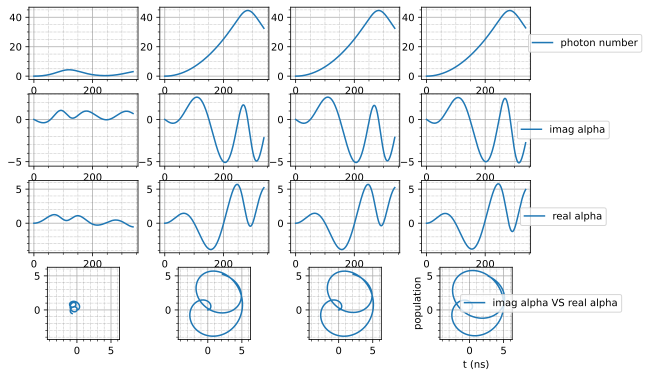

In [31]:
plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=True,fix_ylim=True,plot_only_pn_alpha= True)

In [23]:
interactive_heatmap(results[1], product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=675), Output(…

In [32]:
def compute_contrast(results, res_idx1,res_idx2,# Which two results to compute contrast between
                     coeff, # in GHz
                     a,w_d,tlist,
                     fourier):
    
    # Step-1 compute expectation of alpha and put it in result.expect
    a_op = jnp.array(a.full())

    vectorized_compute_expectation = get_vectorized_compute_expectation_function()

    alphas = []
    for i in [res_idx1,res_idx2]:
        if hasattr(results[i], 'y'):
            states = jnp.array(results[i].y)  # assuming y contains JAX arrays or density matrices (obtained from qiskit solver)
        elif hasattr(results[i], 'states'):
            states = jnp.stack([jnp.array(q.full()) for q in results[i].states])  # assuming states contains QObj or density matrices (obtained from qutip-like solver)
        
        alpha_expect = vectorized_compute_expectation(states, a_op)
        alphas.append(alpha_expect)

    if fourier == True:
        first_dominant_freq =find_dominant_frequency(alphas[0],tlist)
    else:
        first_dominant_freq = w_d

    alphas[0] = alphas[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alphas[1] = alphas[1]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)


    # Step-2 do integration
    squared_diff = np.square(abs(alphas[0]-alphas[1]))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                         (tlist[i]-tlist[i-1])*coeff*squared_diff[i]
                         )
    # Step-3 Plot
    plt.figure()
    plt.plot(tlist, integrals, label='Integral')
    plt.plot(tlist, squared_diff, label='Squared Difference')
    plt.yscale('log')
    plt.yticks([0.1,1, 2, 3, 4, 5, 6, 7, 8, 9, 10,100])
    plt.legend()
    plt.grid()
    plt.show()


# From the photon counting statistics paper, the coefficient should be kappa squared. I plotted contrast of both kappa and kappa squared.

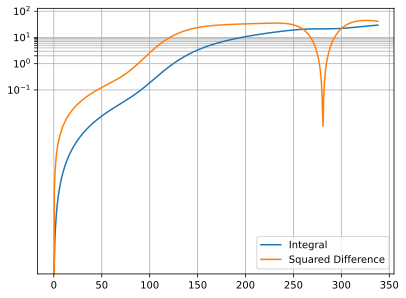

In [33]:
compute_contrast(results = results, 
                 res_idx1= 0, 
                 res_idx2 = 1,
                coeff = kappa,
                a = a,w_d = w_d,tlist = results[0].times,
                fourier = True)

# On reference states:

In [12]:
state_0_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(1,0)])
state_1_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(2,0)])
state_plus_dressed = (state_0_dressed  +  state_1_dressed).unit()
state_minus_dressed = (state_0_dressed - state_1_dressed).unit()
initial_states  = [state_0_dressed,state_1_dressed,state_plus_dressed,state_minus_dressed ]


products_to_keep = []
for ol in range(8):
    products_to_keep.append([0,ol])
for ql in range(1,10):
    for ol in range(8):
        products_to_keep.append([ql,ol])

def truncate_function(qobj):
    return truncate_custom(qobj, products_to_keep, product_to_dressed)


a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
a_trunc = truncate_function(a)

(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])
diag_dressed_hamiltonian = truncate_function(diag_dressed_hamiltonian)


# w_d = transition_frequency(hilbertspace,product_to_dressed[(0,0)],product_to_dressed[(0,1)] )
# w_d_1 = transition_frequency(hilbertspace,product_to_dressed[(0,7)],product_to_dressed[(0,8)] )


tot_time =500
tlist = np.linspace(0, tot_time, tot_time*2)
# kappa = 0.005
# decay_term = np.sqrt(kappa) * a_trunc
# stop_t = abs(a[product_to_dressed[(0,0)],product_to_dressed[(0,1)]])/amp1


write_function()

from temp_functions import mesolve_and_pad, square_cos, square_cos_part1, square_cos_part2
H_with_drive = [
    diag_dressed_hamiltonian,
    [a_trunc+a_trunc.dag(), square_cos],
    # [a_trunc+a_trunc.dag(), square_cos_part2]
]

tomo_results = [None] * 4
with ProcessPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(mesolve_and_pad, 
                               rho0=truncate_function(initial_states[i]), 
                               H_with_drive=H_with_drive,
                               tlist=tlist, 
                               full_dim=hilbertspace.dimension,
                            #    c_ops = [decay_term],  
                               ): i for i in range(4)}
    
    for future in concurrent.futures.as_completed(futures):
        original_index = futures[future]
        tomo_results[original_index] = future.result()


os.remove('temp_functions.py')

10.0%. Run time:   1.45s. Est. time left: 00:00:00:13
10.0%. Run time:   1.45s. Est. time left: 00:00:00:13
10.0%. Run time:   1.47s. Est. time left: 00:00:00:13
10.0%. Run time:   1.48s. Est. time left: 00:00:00:13
20.0%. Run time:   3.28s. Est. time left: 00:00:00:13
20.0%. Run time:   3.28s. Est. time left: 00:00:00:13
20.0%. Run time:   3.33s. Est. time left: 00:00:00:13
20.0%. Run time:   3.36s. Est. time left: 00:00:00:13
30.0%. Run time:   5.10s. Est. time left: 00:00:00:11
30.0%. Run time:   5.10s. Est. time left: 00:00:00:11
30.0%. Run time:   5.19s. Est. time left: 00:00:00:12
30.0%. Run time:   5.23s. Est. time left: 00:00:00:12
40.0%. Run time:   6.92s. Est. time left: 00:00:00:10
40.0%. Run time:   6.92s. Est. time left: 00:00:00:10
40.0%. Run time:   7.04s. Est. time left: 00:00:00:10
40.0%. Run time:   7.09s. Est. time left: 00:00:00:10
50.0%. Run time:   8.58s. Est. time left: 00:00:00:08
50.0%. Run time:   8.61s. Est. time left: 00:00:00:08
50.0%. Run time:   8.69s. Es

In [13]:
if tomo_results[0].states[0].type == 'ket':
    dm_tomo_results_list = []
    for result in tomo_results:
        new_result = qutip.solver.Result()
        new_result.states = [ket2dm(state) for state in result.states]
        new_result.times = result.times
        dm_tomo_results_list.append(new_result)
else:
    dm_tomo_results_list = tomo_results

In [14]:
len(dm_tomo_results_list[0].times)

1000

In [15]:
for result in dm_tomo_results_list:
    result.states = result.states[::10]
    result.times = result.times[::10]


In [16]:
import shutil
dir_name = 'temp_tomo'
if os.path.exists(dir_name):
    shutil.rmtree(dir_name)
os.mkdir(dir_name)
tasks = [(dm_tomo_results_list, 
          f'{dir_name}/res_{i}_state_{j}.pkl',
          i, j,  product_to_dressed, qubit_level, osc_level, 1, 2) 
         for i in range(len(dm_tomo_results_list)) 
         for j in range(len(dm_tomo_results_list[i].states))]

from multiprocessing import Pool

with Pool(processes=6) as pool:
    pool.map(compute_and_store_2_level_dm, tasks)

In [17]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)

states_ideal  = [zero,
              one,
              (zero +  one).unit(),
              (zero - one).unit() ]


num_initial_states = len(dm_tomo_results_list)
num_time_steps = len(dm_tomo_results_list[0].times)
two_level_states = []
for i in range(num_initial_states) :
    two_level_states.append([])
    for j in range(num_time_steps):
        with open(f'{dir_name}/res_{i}_state_{j}.pkl', 'rb') as f:
            state = pickle.load(f)
        two_level_states[-1].append(state)


Text(0.5, 0, 'ns')

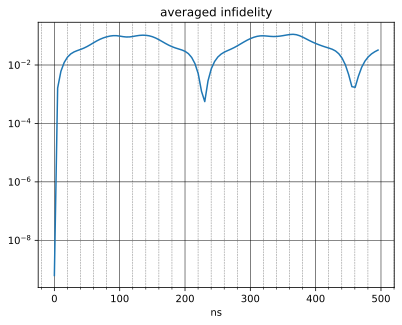

In [18]:
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*dm_ideal))

    return 1-sum(fid)/len(fid)
    


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [states[idx] for states in two_level_states]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x)


plt.plot(dm_tomo_results_list[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

In [123]:
# plt.plot(dm_tomo_results_list[0].times,phase,label = f'phase')

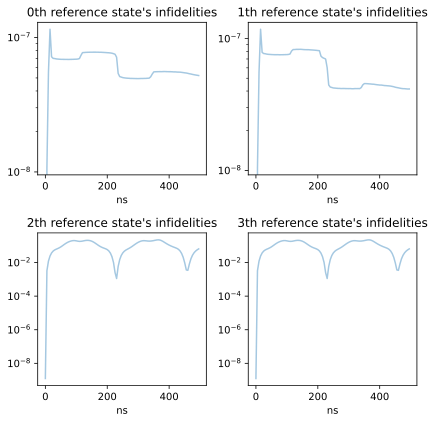

In [19]:
def calc_fidelity_with_phase(phase,dm,state_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    return 1-qutip.fidelity(dm, gate*state_ideal)

    

phases = []
infidelities = []
for i, states in enumerate(two_level_states):
    phases.append([])
    infidelities.append([])
    for idx in range(num_time_steps):
        dm = states[idx]
        def objective_function(params):
            return calc_fidelity_with_phase(params[0], dm, states_ideal[i])
        initial_phase = [0.0]
        opt_result = minimize(objective_function, initial_phase,method="COBYLA")
        phases[-1].append(opt_result.x)
        infidelities[-1].append(opt_result.fun)
# for i in range(4):
#     plt.plot(dm_tomo_results_list[0].times,infidelities[i],label = f'{i}th infidelities',alpha = 0.4)
# plt.title("infidelities")
# plt.xlabel("ns")
# plt.legend()

fig, axs = plt.subplots(2, 2, figsize=(6, 6))
axs = axs.flatten()
for i in range(4):
    axs[i].plot(dm_tomo_results_list[0].times, infidelities[i], label=f'{i}th infidelities', alpha=0.4)
    axs[i].set_title(f"{i}th reference state's infidelities")
    axs[i].set_xlabel("ns")
    axs[i].set_yscale('log')
    # axs[i].legend()


plt.tight_layout()
plt.show()